In [1]:
from ultralytics import YOLO
from pathlib import Path
import torch
import os
import yaml
import cv2
import matplotlib.pyplot as plt

In [2]:
print("=" * 60)

print("PyTorch Version :", torch.__version__)
print("CUDA Version    :", torch.version.cuda)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

print("=" * 60)

PyTorch Version : 2.11.0+cu128
CUDA Version    : 12.8
CUDA Available  : True
GPU : NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
BASE_DIR = Path.cwd().parent

print(BASE_DIR)

c:\Users\Drishi\Desktop\Code Arcade\projects\Digital Image Processing Toolkit\AI_training


In [4]:
DATASET_PATH = BASE_DIR / "Dataset" / "drone_dataset"

MODEL_PATH = Path.cwd() / "yolo11s.pt"

print("Dataset :", DATASET_PATH)
print("Model   :", MODEL_PATH)

Dataset : c:\Users\Drishi\Desktop\Code Arcade\projects\Digital Image Processing Toolkit\AI_training\Dataset\drone_dataset
Model   : c:\Users\Drishi\Desktop\Code Arcade\projects\Digital Image Processing Toolkit\AI_training\Notebooks\yolo11s.pt


In [5]:
print("Dataset Exists :", DATASET_PATH.exists())
print("Model Exists   :", MODEL_PATH.exists())
print("YAML Exists    :", (DATASET_PATH / "data.yaml").exists())

Dataset Exists : True
Model Exists   : True
YAML Exists    : True


In [6]:
with open(DATASET_PATH / "data.yaml") as f:
    data = yaml.safe_load(f)

data

{'path': 'C:/Users/Drishi/Desktop/Code Arcade/projects/Digital Image Processing Toolkit/AI_training/Dataset/drone_dataset',
 'train': 'train/images',
 'val': 'valid/images',
 'nc': 1,
 'names': {0: 'drone'}}

In [7]:
model = YOLO(str(MODEL_PATH))

In [8]:
results = model.train(

    data=str(DATASET_PATH / "data.yaml"),

    epochs=50,

    imgsz=640,

    batch=16,

    device=0,

    workers=8,

    optimizer="auto",

    pretrained=True,

    project=str(BASE_DIR / "Runs"),

    name="Drone_Detection",

    exist_ok=True,

    verbose=True,

    plots=True,

    save=True,

    val=True
)

New https://pypi.org/project/ultralytics/8.4.115 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.104  Python-3.10.11 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Drishi\Desktop\Code Arcade\projects\Digital Image Processing Toolkit\AI_training\Dataset\drone_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, k

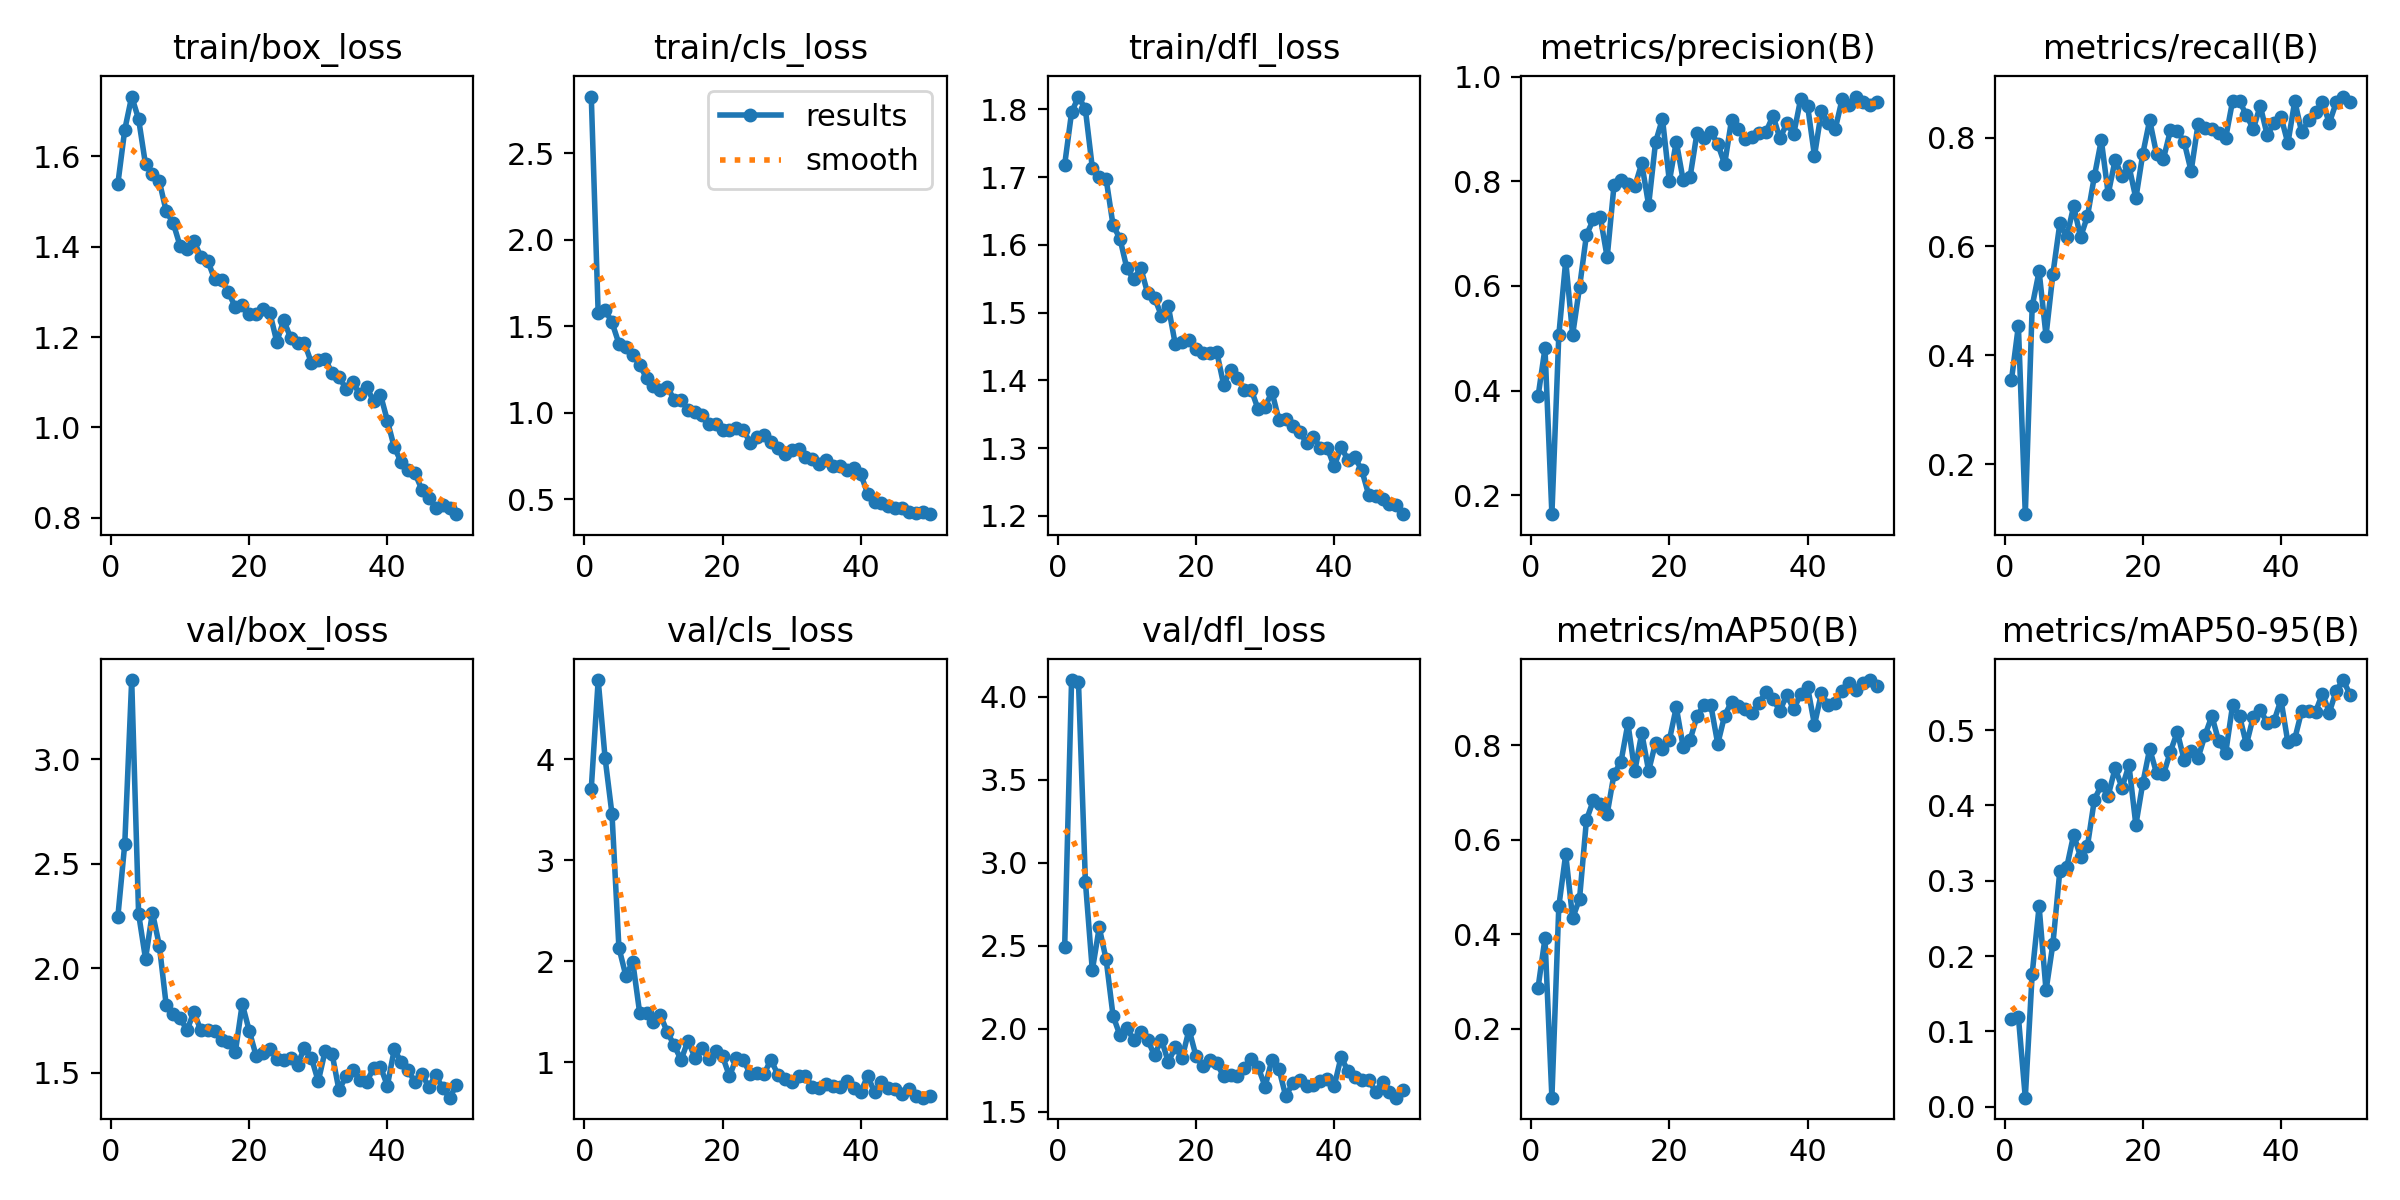

In [9]:
from PIL import Image

results_image = BASE_DIR / "Runs" / "Drone_Detection" / "results.png"

Image.open(results_image)

In [10]:
weights = BASE_DIR / "Runs" / "Drone_Detection" / "weights"

print(list(weights.iterdir()))

[WindowsPath('c:/Users/Drishi/Desktop/Code Arcade/projects/Digital Image Processing Toolkit/AI_training/Runs/Drone_Detection/weights/best.pt'), WindowsPath('c:/Users/Drishi/Desktop/Code Arcade/projects/Digital Image Processing Toolkit/AI_training/Runs/Drone_Detection/weights/last.pt')]


In [ ]:
best_model = YOLO(
    BASE_DIR / "Runs" / "Drone_Detection" / "weights" / "best.pt"
)

best_model.predict(
    source=str(DATASET_PATH / "valid/images"),
    conf=0.25,
    save=True
)